Accuracy: 0.8333

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84        48
           1       0.81      0.83      0.82        42

    accuracy                           0.83        90
   macro avg       0.83      0.83      0.83        90
weighted avg       0.83      0.83      0.83        90


Confusion Matrix:
[[40  8]
 [ 7 35]]

Model Coefficients: [0.65547431 1.12077501 0.39901054]
Model Intercept: 0.1783050320435804


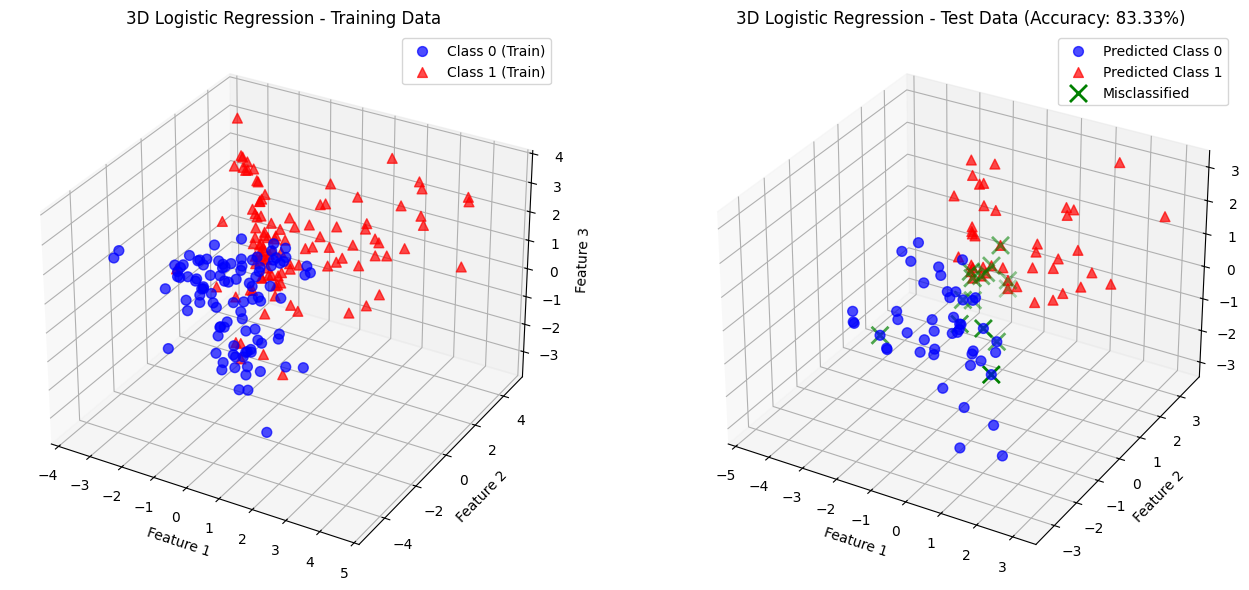


Sample Predictions (First 10):
Sample 1: Predicted Class = 0, Probability = [0.74999508 0.25000492]
Sample 2: Predicted Class = 0, Probability = [0.94796986 0.05203014]
Sample 3: Predicted Class = 0, Probability = [0.89313215 0.10686785]
Sample 4: Predicted Class = 0, Probability = [0.98635814 0.01364186]
Sample 5: Predicted Class = 1, Probability = [0.0750408 0.9249592]
Sample 6: Predicted Class = 0, Probability = [0.88936941 0.11063059]
Sample 7: Predicted Class = 1, Probability = [0.47688923 0.52311077]
Sample 8: Predicted Class = 1, Probability = [0.23128222 0.76871778]
Sample 9: Predicted Class = 1, Probability = [0.47862756 0.52137244]
Sample 10: Predicted Class = 0, Probability = [0.79533411 0.20466589]


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Generate sample data with more features for better 3D visualization
X, y = make_classification(n_samples=300, n_features=3, n_informative=3, 
                           n_redundant=0, n_clusters_per_class=2, 
                           random_state=42, n_classes=2)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nModel Coefficients: {model.coef_[0]}")
print(f"Model Intercept: {model.intercept_[0]}")

# 3D Visualization
fig = plt.figure(figsize=(14, 6))

# Plot 1: 3D Scatter plot of training data
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], X_train[y_train==0, 2], 
                       c='blue', marker='o', s=50, label='Class 0 (Train)', alpha=0.7)
scatter2 = ax1.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], X_train[y_train==1, 2], 
                       c='red', marker='^', s=50, label='Class 1 (Train)', alpha=0.7)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')
ax1.set_title('3D Logistic Regression - Training Data')
ax1.legend()

# Plot 2: 3D Scatter plot of test data with predictions
ax2 = fig.add_subplot(122, projection='3d')
scatter3 = ax2.scatter(X_test[y_pred==0, 0], X_test[y_pred==0, 1], X_test[y_pred==0, 2], 
                       c='blue', marker='o', s=50, label='Predicted Class 0', alpha=0.7)
scatter4 = ax2.scatter(X_test[y_pred==1, 0], X_test[y_pred==1, 1], X_test[y_pred==1, 2], 
                       c='red', marker='^', s=50, label='Predicted Class 1', alpha=0.7)
# Highlight misclassified points
misclassified = y_test != y_pred
ax2.scatter(X_test[misclassified, 0], X_test[misclassified, 1], X_test[misclassified, 2],
           c='green', marker='x', s=150, linewidths=2, label='Misclassified')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')
ax2.set_title(f'3D Logistic Regression - Test Data (Accuracy: {accuracy:.2%})')
ax2.legend()

plt.tight_layout()
plt.show()

# Display sample predictions with probabilities
print("\nSample Predictions (First 10):")
for i in range(min(10, len(X_test))):
    print(f"Sample {i+1}: Predicted Class = {y_pred[i]}, Probability = {y_pred_proba[i]}")